# Importacion de librerias

In [1]:
from wget import download
from os import path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Descarga de datos

In [2]:
datos_arbolado= pd.read_csv("../data/arbolado-publico-lineal-2017-2018.csv")

/tmp/ipykernel_7299/175755440.py:1: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  datos_arbolado= pd.read_csv("../data/arbolado-publico-lineal-2017-2018.csv")


# Apertura de datos

In [3]:
datos_arbolado.head()

,long,lat,nro_registro,tipo_activ,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,26779,Lineal,1,NaN,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,30887,Lineal,1,NaN,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,30904,Lineal,1,NaN,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,31336,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,31337,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0


In [4]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364677 non-null  object 
 8   calle_chapa            363721 non-null  object 
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      370180 non-null  object 
 12  ancho_acera            367083 non-null  object 
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

In [5]:
datos_arbolado.describe()

,long,lat,comuna,diametro_altura_pecho,altura_arbol
count,354838.000000,354838.000000,370180.000000,369894.000000,365858.000000
mean,-58.458791,-34.612473,9.143735,31.986864,9.036132
std,0.041514,0.033695,3.876242,21.267623,4.894625
min,-58.530458,-34.697333,1.000000,0.000000,1.000000
25%,-58.491269,-34.637834,6.000000,17.000000,6.000000
50%,-58.465865,-34.615023,10.000000,29.000000,8.000000
75%,-58.428583,-34.586580,12.000000,43.000000,12.000000
max,-58.354003,-34.535972,15.000000,199.000000,40.000000


# Visualizacion de datos crudos

## Latitud y longitud expresadas en forma de mapa


### Imprimir scatter que representa el mapa de la ciudad en relacion a los arboles


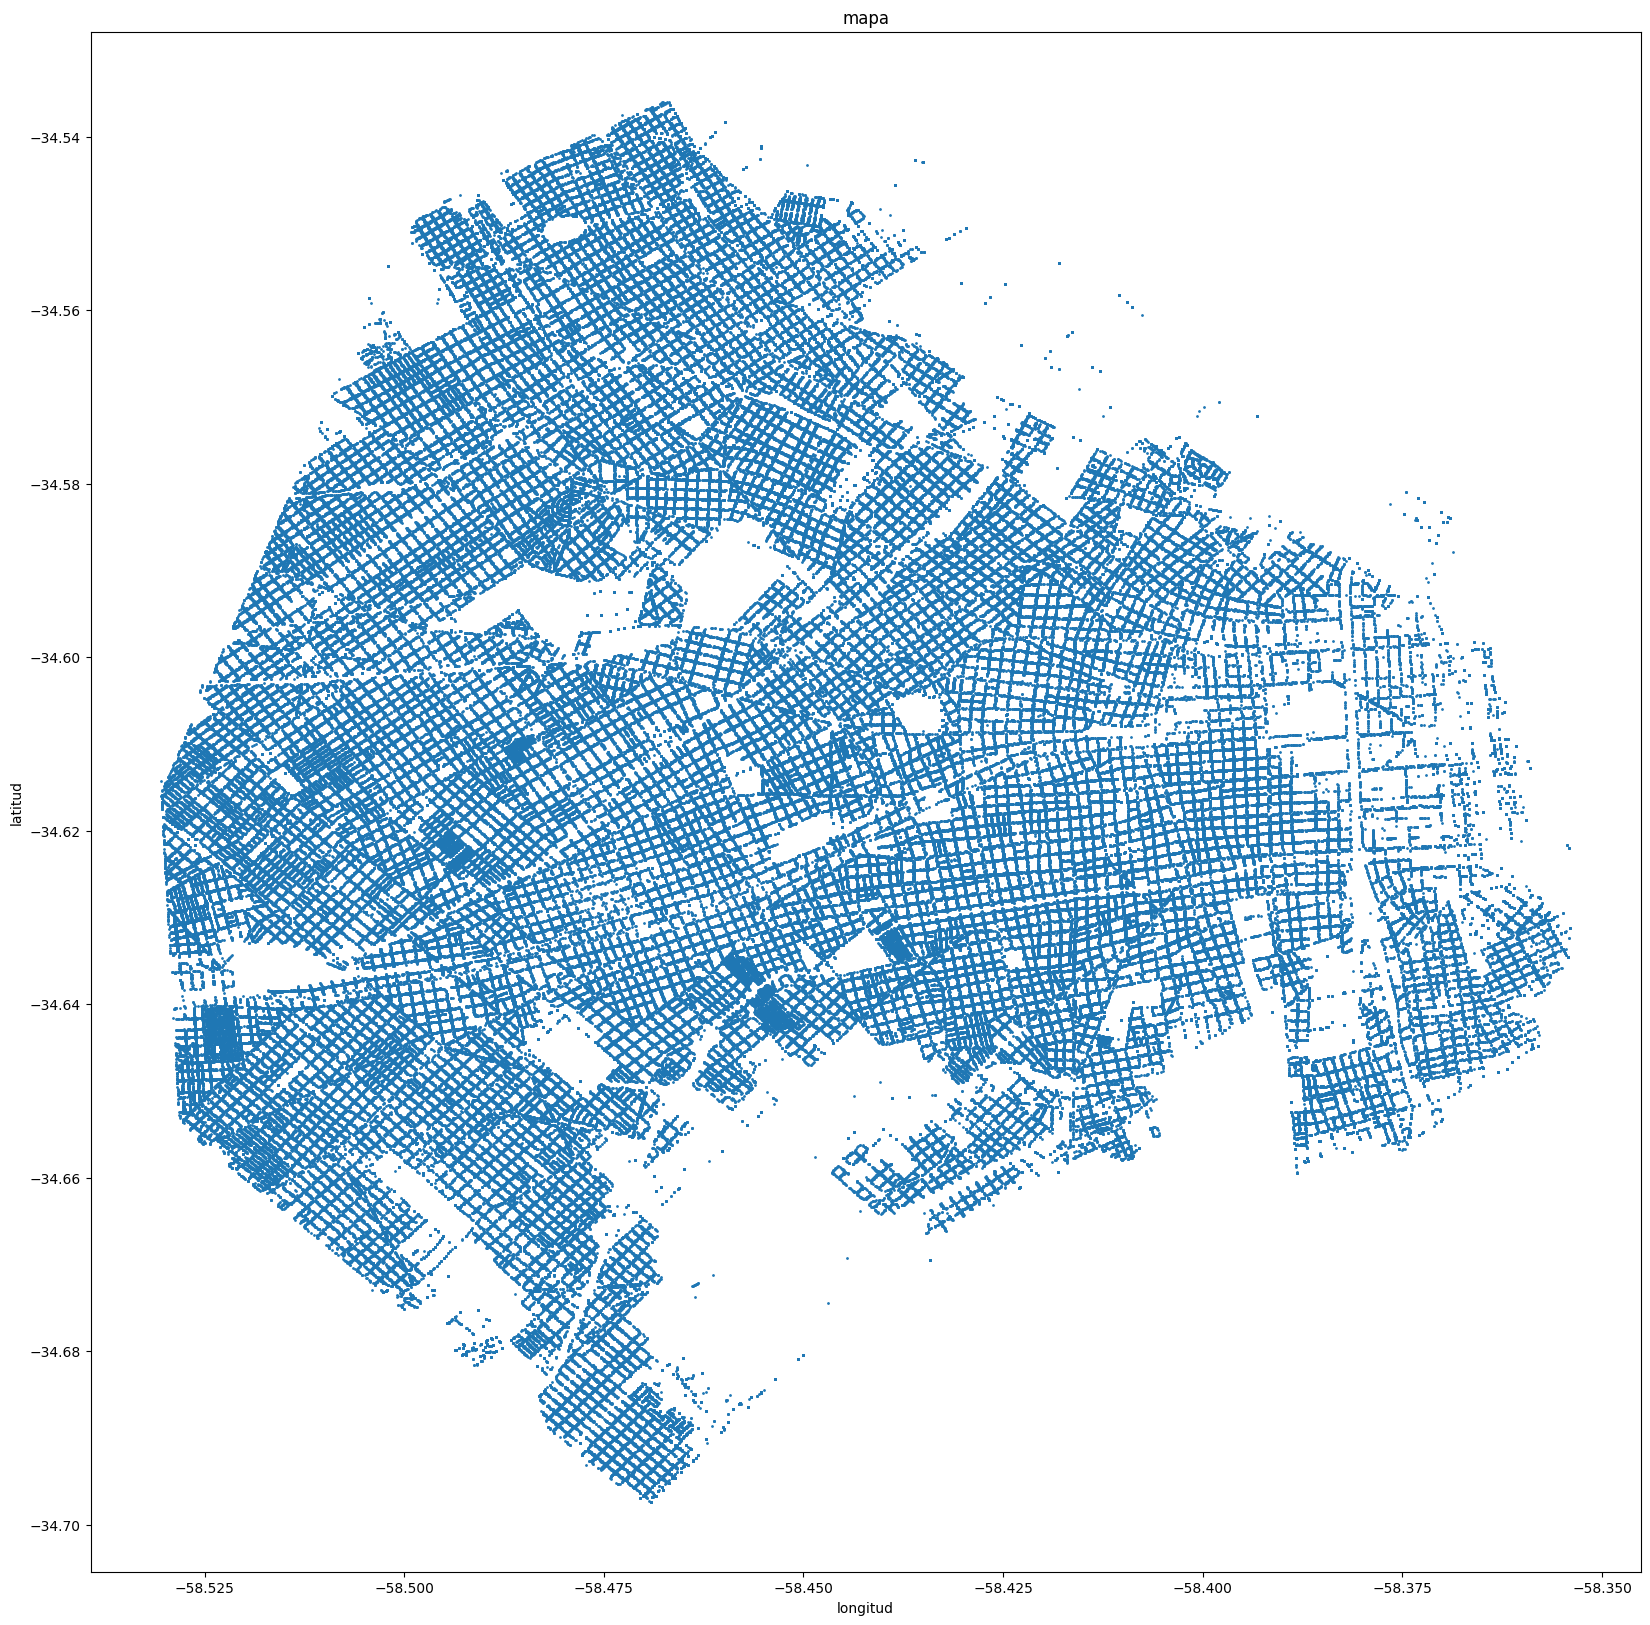

In [6]:
plt.figure(figsize=(20,20))
plt.scatter(datos_arbolado['long'], datos_arbolado['lat'], s=1)
plt.xlabel("longitud")
plt.ylabel("latitud")
plt.title("mapa")

plt.show()

Limpieza nulos en latitud y longitud

In [7]:
datos_arbolado= datos_arbolado.dropna(subset=['lat','long'])
datos_arbolado

,long,lat,nro_registro,tipo_activ,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,26779,Lineal,1,NaN,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,30887,Lineal,1,NaN,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,30904,Lineal,1,NaN,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,31336,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,31337,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370125,-58.477279,-34.582165,545682,Lineal,15,244,Marsella,2500.0,NaN,MARSELLA,LD 13,Enterolobium contortisiliquum,NaN,Ocupada,Regular,A Nivel,9.0,4.0
370169,-58.470559,-34.595531,545935,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA1,Tipuana tipu,NaN,Ocupada,NaN,NaN,62.0,16.0
370170,-58.470559,-34.595531,545936,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA2,Tipuana tipu,NaN,Ocupada,NaN,NaN,76.0,16.0
370171,-58.470559,-34.595531,545937,Lineal,15,423,Punta Arenas Av.,1500.0,1500.0,NaN,LA3,Tipuana tipu,NaN,Ocupada,NaN,NaN,57.0,16.0


## nro_registro
Representa un identificador unico para cada arbol

In [8]:
datos_arbolado['nro_registro']

0          26779
1          30887
2          30904
3          31336
4          31337
           ...  
370125    545682
370169    545935
370170    545936
370171    545937
370172    545938
Name: nro_registro, Length: 354838, dtype: object

In [9]:
datos_arbolado=datos_arbolado.drop('nro_registro',axis=1)

## tipo_actividad

### ¿Que representa el tipo de actividad?
analizar la variable, viendo que tipos de actividad hay y que significa cada una

In [10]:
datos_arbolado['tipo_activ'].value_counts()
datos_arbolado= datos_arbolado.drop('tipo_activ',axis=1)


Los tipos de actividad representan el tipo de relevamiento o censo que el arbol forma parte del arbolado publico lineal.
Los tipos son lineal y de calle. que representan lo mismo. por lo tanto el conjunto de datos representa arboles de alumbrado publico, es decir de la vereda.


## Comunas


### Como se diferencian las comunas?

In [11]:
datos_arbolado['comuna'].value_counts()

comuna
12    37111
9     35796
11    35478
10    32445
4     30066
15    28214
13    27267
7     25382
14    21162
8     19898
5     15112
6     15083
3     13267
1     11647
2      6910
Name: count, dtype: int64

/tmp/ipykernel_7299/204778770.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))


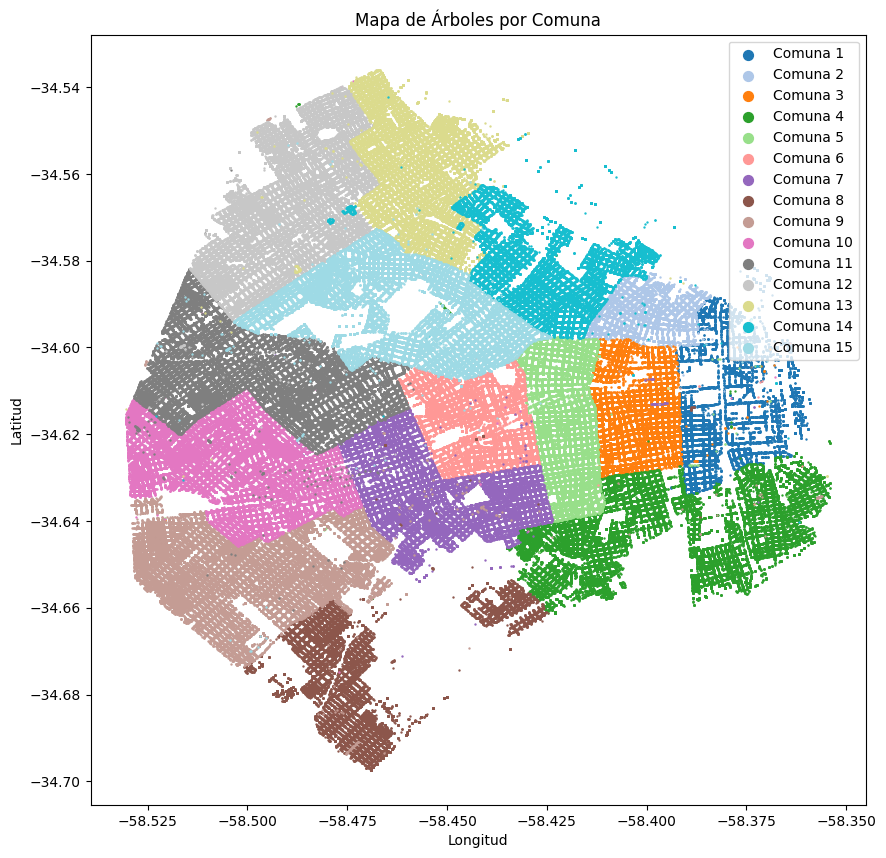

In [12]:
plt.figure(figsize=(10, 10))
categorias = sorted(datos_arbolado['comuna'].unique())
colores = plt.cm.get_cmap('tab20', len(categorias))

for i, comuna in enumerate(categorias):
    subset = datos_arbolado[datos_arbolado['comuna'] == comuna]
    plt.scatter(
        subset['long'],
        subset['lat'],
        s=0.5,
        color=colores(i),
        label=f'Comuna {int(comuna)}'
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles por Comuna")
plt.legend(markerscale=10)
plt.show()

In [13]:
import pandas as pd
import geopandas as gpd

# Asumo que 'datos_arbolado' es tu DataFrame con lat/lon
# y 'comunas.geojson' es el mapa que descargaste.

# --- 1. Cargar el mapa de Polígonos (las comunas) ---
gdf_comunas = gpd.read_file('../data/caba_comunas.geojson')

# Inspeccionemos qué columnas tiene (ej. 'comuna_id', 'nombre')
print("Columnas del mapa de comunas:")
print(gdf_comunas.head())

# --- 2. Convertir tu DataFrame de árboles a un GeoDataFrame (Puntos) ---
# Usamos lat/lon para crear una geometría de tipo 'Point'
gdf_arboles = gpd.GeoDataFrame(
    datos_arbolado, 
    geometry=gpd.points_from_xy(datos_arbolado.long, datos_arbolado.lat)
)

# --- 3. ¡CRÍTICO! Asegurar que ambos usen el mismo CRS ---
# CRS (Sistema de Referencia de Coordenadas) es el "idioma" del mapa.
# EPSG:4326 es el estándar para lat/lon (WGS84)
gdf_arboles.set_crs(epsg=4326, inplace=True)

# Verificamos el CRS de las comunas y lo convertimos si es necesario
print(f"\nCRS Árboles: {gdf_arboles.crs}")
print(f"CRS Comunas: {gdf_comunas.crs}")

if gdf_arboles.crs != gdf_comunas.crs:
    print("Convirtiendo CRS de comunas para que coincida...")
    gdf_comunas = gdf_comunas.to_crs(gdf_arboles.crs)

Columnas del mapa de comunas:
   ID          OBJETO  COMUNAS  \
0   1  LIMITE COMUNAL      2.0   
1   3  LIMITE COMUNAL      6.0   
2   6  LIMITE COMUNAL     10.0   
3   7  LIMITE COMUNAL     11.0   
4   8  LIMITE COMUNAL     12.0   

                                             BARRIOS     PERIMETRO  \
0                                           RECOLETA  21452.838648   
1                                          CABALLITO  10990.964471   
2  FLORESTA - MONTE CASTRO - VELEZ SARSFIELD - VE...  18332.037457   
3  VILLA DEL PARQUE - VILLA  DEVOTO - VILLA GRAL....  19987.696155   
4  COGHLAN - SAAVEDRA - VILLA PUEYRREDON - VILLA ...  17232.189372   

           AREA                                           geometry  
0  6.317265e+06  MULTIPOLYGON (((-58.38 -34.57002, -58.38002 -3...  
1  6.851029e+06  MULTIPOLYGON (((-58.43061 -34.60705, -58.43056...  
2  1.265656e+07  MULTIPOLYGON (((-58.48834 -34.62016, -58.4882 ...  
3  1.412004e+07  MULTIPOLYGON (((-58.49838 -34.59637, -58.49718...  

In [14]:
# Renombramos la columna de comuna del mapa para evitar confusión
# Supongamos que en 'gdf_comunas' la comuna se llama 'comuna' o 'COMUNA_NRO'
# (ajusta 'COMUNA_NRO' al nombre real que viste en el head())
gdf_comunas_limpio = gdf_comunas.rename(columns={'COMUNAS': 'comuna_correcta'})

# --- El comando clave: Spatial Join ---
# how='left': Mantenemos todos los árboles (filas de la izquierda)
# predicate='within': El punto debe estar 'dentro' del polígono
gdf_arboles_corregido = gpd.sjoin(
    gdf_arboles, 
    gdf_comunas_limpio[['comuna_correcta', 'geometry']], # Solo queremos esta columna
    how='left', 
    predicate='within'
)

# Ahora 'gdf_arboles_corregido' tiene tus columnas originales
# MÁS una nueva columna: 'comuna_correcta'

In [15]:
# --- 1. Comparar la comuna original con la correcta ---
# (Asumo que tu columna original se llama 'comuna_nombre' o 'comuna_id')
original_col = 'comuna' # Ajusta este nombre
correcta_col = 'comuna_correcta'

# Cuenta cuántos no coinciden (excluyendo los que quedaron nulos)
diferencias = gdf_arboles_corregido[
    gdf_arboles_corregido[original_col] != gdf_arboles_corregido[correcta_col]
].shape[0]

print(f"\nSe encontraron {diferencias} árboles con la comuna incorrecta.")

# --- 2. Reemplazar la columna original ---
# Creamos la columna final de 'comuna' con los valores corregidos
# (Usamos la corregida, y si falló el join, dejamos la original)
datos_arbolado['comuna'] = gdf_arboles_corregido[correcta_col].fillna(datos_arbolado[original_col])

print("\nLimpieza completada. La columna 'comuna_final' tiene los datos corregidos.")


Se encontraron 2317 árboles con la comuna incorrecta.

Limpieza completada. La columna 'comuna_final' tiene los datos corregidos.


/tmp/ipykernel_7299/204778770.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))


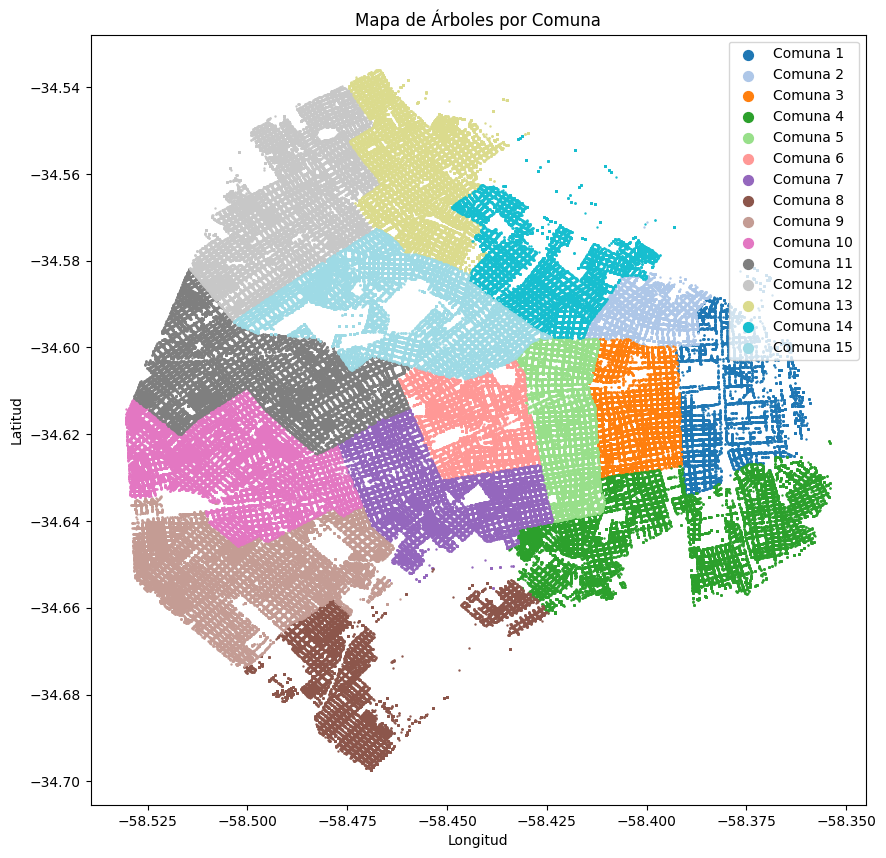

In [16]:
plt.figure(figsize=(10, 10))
categorias = sorted(datos_arbolado['comuna'].unique())
colores = plt.cm.get_cmap('tab20', len(categorias))

for i, comuna in enumerate(categorias):
    subset = datos_arbolado[datos_arbolado['comuna'] == comuna]
    plt.scatter(
        subset['long'],
        subset['lat'],
        s=0.5,
        color=colores(i),
        label=f'Comuna {int(comuna)}'
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles por Comuna")
plt.legend(markerscale=10)
plt.show()

## Manzanas

### Como se diferencia las manzanas?

In [17]:
manzanas= datos_arbolado['manzana'].unique()
print(list(manzanas))

[nan, '13', '591', '137', '419', '6', '136', '561', '565', '568', '569', '572', '575', '998', '159', '119 b', '119 c', '668', '616', '687', '611', '614', '667', '607', '615', '622', '613', '620', '666', '604', '664', '610', '663', '665', '608', '619', '543', '685', '652', '675', '678', '679', '680', '676', '661', '671', '674', '682', '656', '658', '657', '655', '603', '660', '670', '609', '681', '686', '631', '600', '626', '595', '589', '629', '628', '587', '625', '594', '639', '633bb', '633bo', '633', '627', '643', '644', '642', '647', '632', '645', '590', '638', '599', '630', '637', '596', '601', '651', '650', '640', '0', '641', '634', '446 e', '555', '646', '648', '573', '559', '673', '63', '684', '654', '621', '677', '672', '618', '579', '617', '683', '670 bis', '659', '653', '672borrar', '2', '62', '135', '380', '381', '382', '383', '384', '385', '491', '496', '512', '560', '588', '597', '598', '605', '606', '612', '167', '192', '200', '32', '182', '346a', '246', '263', '276', '3'

## Calle_nombre

In [18]:
# Convierte al tipo de dato 'string' moderno de Pandas
# (Y usamos .loc para evitar el SettingWithCopyWarning)
datos_arbolado.loc[:, 'calle_nombre'] = datos_arbolado['calle_nombre'].astype('string')

In [19]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354838 entries, 0 to 370172
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   comuna                 354838 non-null  float64
 3   manzana                214238 non-null  object 
 4   calle_nombre           354838 non-null  object 
 5   calle_altura           351661 non-null  object 
 6   calle_chapa            350970 non-null  object 
 7   direccion_normalizada  353641 non-null  object 
 8   ubicacion              347949 non-null  object 
 9   nombre_cientifico      354838 non-null  object 
 10  ancho_acera            352713 non-null  object 
 11  estado_plantera        354838 non-null  object 
 12  ubicacion_plantera     354083 non-null  object 
 13  nivel_plantera         354022 non-null  object 
 14  diametro_altura_pecho  354562 non-null  f

In [20]:
datos_arbolado['calle_nombre'].value_counts().nlargest(10)
datos_arbolado[datos_arbolado['calle_nombre']=='Del Libertador, Av']

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
518,-58.379661,-34.590146,1.0,NaN,"Del Libertador, Av",400.0,408.0,DEL LIBERTADOR AV. 408,LD,Jacaranda mimosifolia,6,Ocupada,Regular,A nivel,37.0,8.0
519,-58.379661,-34.590146,1.0,NaN,"Del Libertador, Av",400.0,408.0,DEL LIBERTADOR AV. 408,LD,Jacaranda mimosifolia,6,Ocupada,Regular,A nivel,30.0,9.0
520,-58.374144,-34.593659,1.0,NaN,"Del Libertador, Av",400.0,6.0,DEL LIBERTADOR AV. 6,Exacta,Jacaranda mimosifolia,6,Ocupada,Regular,A nivel,39.0,9.0
521,-58.380415,-34.589736,1.0,NaN,"Del Libertador, Av",400.0,498.0,DEL LIBERTADOR AV. 498,LD,Jacaranda mimosifolia,6,Ocupada,Regular,A nivel,40.0,8.0
522,-58.380415,-34.589736,1.0,NaN,"Del Libertador, Av",400.0,498.0,DEL LIBERTADOR AV. 498,LD,Jacaranda mimosifolia,6,Ocupada,Regular,A nivel,40.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367720,-58.423058,-34.571056,14.0,NaN,"Del Libertador, Av",3900.0,NaN,DEL LIBERTADOR AV.,LA,Tipuana tipu,4,Ocupada,Regular,A nivel,62.0,16.0
367721,-58.423058,-34.571056,14.0,NaN,"Del Libertador, Av",3900.0,NaN,DEL LIBERTADOR AV.,LA,Tipuana tipu,4,Ocupada,Regular,A nivel,50.0,15.0
367722,-58.423058,-34.571056,14.0,NaN,"Del Libertador, Av",3900.0,NaN,DEL LIBERTADOR AV.,LA,Tipuana tipu,4,Ocupada,Regular,A nivel,66.0,18.0
367814,-58.421779,-34.572065,14.0,NaN,"Del Libertador, Av",3800.0,NaN,DEL LIBERTADOR AV.,NaN,Tipuana tipu,9,Ocupada,Regular,A nivel,63.0,17.0


In [21]:
datos_arbolado['calle_nombre'].isna().sum()

np.int64(0)

## calle_altura

In [22]:
datos_arbolado['calle_altura'].value_counts()
print(datos_arbolado['calle_altura'].isna().sum())
datos_arbolado= datos_arbolado[datos_arbolado['calle_altura'].notna()]

3177


Quitamos las que tengan altura nula, daod que estas nos van a servir para poder limpiar ancho_acera, y no podemos confiar de los que no tienen altura, dado que no podemos saber si sus datos son correctos

### Calle_chapa

In [23]:

dato=datos_arbolado['calle_chapa'].astype(str).str.replace(r'\D+', '', regex=True)
dato= pd.to_numeric(dato, errors='coerce')
print(dato)
datos_arbolado['calle_chapa']=dato.astype('Int32')



0         11200.0
1         13450.0
2          8480.0
3          9320.0
4          9320.0
           ...   
370125        NaN
370169    15000.0
370170    15000.0
370171    15000.0
370172    15000.0
Name: calle_chapa, Length: 351661, dtype: float64


In [24]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351661 entries, 0 to 370172
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   351661 non-null  float64
 1   lat                    351661 non-null  float64
 2   comuna                 351661 non-null  float64
 3   manzana                212624 non-null  object 
 4   calle_nombre           351661 non-null  object 
 5   calle_altura           351661 non-null  object 
 6   calle_chapa            347793 non-null  Int32  
 7   direccion_normalizada  350471 non-null  object 
 8   ubicacion              344803 non-null  object 
 9   nombre_cientifico      351661 non-null  object 
 10  ancho_acera            349546 non-null  object 
 11  estado_plantera        351661 non-null  object 
 12  ubicacion_plantera     350914 non-null  object 
 13  nivel_plantera         350854 non-null  object 
 14  diametro_altura_pecho  351388 non-null  f

## Direccion_normalizada


In [25]:
datos_arbolado['direccion_normalizada'].value_counts()


direccion_normalizada
OBLIGADO RAFAEL, AV.COSTANERA         231
DORREGO AV.                           212
DEL LIBERTADOR AV.                    179
OBLIGADO RAFAEL, AV.COSTANERA 7200    175
TRIUNVIRATO AV. 5900                  172
                                     ... 
GUARDIA NACIONAL 1046                   1
CAÑADA DE GOMEZ 706                     1
LARRAZABAL AV. 1063                     1
LARRAZABAL AV. 1061                     1
POLA 419                                1
Name: count, Length: 246801, dtype: int64

In [26]:
datos_arbolado=datos_arbolado.drop('direccion_normalizada',axis=1)

## Ubicacion

In [27]:
for idx, val in datos_arbolado['ubicacion'].value_counts().items():
    print(idx, val)

Exacta 234176
LA 51862
LD 44976
LA1 2305
LD1 1988
En frente 865
LA 1 765
LA2 758
LD2 715
LD 1 607
LA3 396
LD3 370
En frente - Exacta 329
LA4 257
LD4 235
LA 2 231
LD 2 218
LA5 195
LD5 166
LA6 159
LA7 128
LD6 123
LA 3 113
En frente - LA 112
LD 3 108
LD7 107
LA8 105
En frente - LD 105
LD 4 96
LA9 95
LD8 84
LA 4 84
EX 81
LA10 78
LD9 66
LA11 63
LA12 60
LD 5 59
LA 5 58
LA13 51
LD10 49
LD 6 46
LA 6 45
LA14 43
LD11 39
LD 7 36
LD12 35
LA 7 35
LD 8 33
LA15 32
Ex 31
LA16 28
Exacta  27
LD13 26
LA 8 26
LD14 25
LA 9 23
Enfrente Ext 23
LD 9 22
LD 10 21
LA17 20
LA18 19
LD 11 19
LA 11 18
LD15 17
LA 10 16
Vereda 16
LD16 16
LA19 16
LA21 14
En frente -  Exacta 13
Exacto 13
LA22 13
LA20 13
LA23 12
LA24 12
LD17 11
la1 10
LA25 10
LD 12 10
LD18 10
La1 10
LA 13 9
LD20 9
LD 14 9
LD22 8
LD19 8
LD 13 8
LA 12 8
LD 1  8
la2 7
LA26 7
LA27 7
ld1 7
LD 15 7
LA 14 7
LA28 7
LD23 7
LD21 7
LD24 6
LD25 6
la3 6
LA 16 6
Enfrente LD1 6
lD1 6
LA 15 6
LA 18 5
LA30 5
LD26 5
la 5
La2 5
LA1  5
LA 17 5
LD28 4
LA29 4
LA 19 4
LA 20 4


In [28]:
datos_arbolado=datos_arbolado.drop('ubicacion',axis=1)

## Nombre_cientifico

In [29]:


dic= datos_arbolado['nombre_cientifico'].value_counts()>4000
print(dic)
nombres_cientificos= datos_arbolado[datos_arbolado['nombre_cientifico'].map(dic)]






nombre_cientifico
Fraxinus pennsylvanica     True
Platanus x acerifolia      True
Ficus benjamina            True
Tilia x moltkei            True
Melia azedarach            True
                          ...  
Abutilon pictum           False
Taxodium ascendens        False
Synadenium grantii        False
Tecoma stans              False
Scutia buxifolia          False
Name: count, Length: 429, dtype: bool


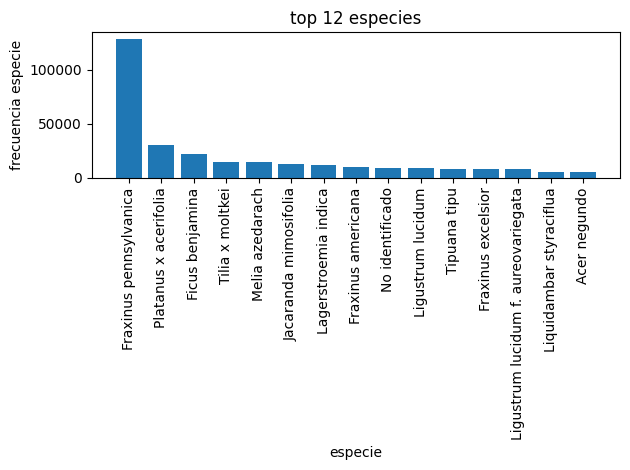

In [30]:


top12= datos_arbolado['nombre_cientifico'].value_counts().nlargest(15)
nombre= top12.index
conteo= top12.values

plt.Figure(figsize=(12,7))

plt.bar(nombre,conteo)
plt.title('top 12 especies')
plt.ylabel('frecuencia especie')
#plt.yscale('log')
plt.xlabel('especie')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [31]:
datos_arbolado[datos_arbolado['nombre_cientifico']=='No identificado']
datos_arbolado['nombre_cientifico']= datos_arbolado['nombre_cientifico'].replace('No identificado')

nombres= nombre.to_list()
datos_arbolado['nombre_cientifico']=np.where(datos_arbolado['nombre_cientifico'].isin(nombres), datos_arbolado['nombre_cientifico'], 'Otra')
datos_arbolado['nombre_cientifico'].value_counts()


/tmp/ipykernel_7299/2379346614.py:2: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  datos_arbolado['nombre_cientifico']= datos_arbolado['nombre_cientifico'].replace('No identificado')


nombre_cientifico
Fraxinus pennsylvanica                 131485
Otra                                    57648
Platanus x acerifolia                   31091
Ficus benjamina                         22212
Tilia x moltkei                         15165
Melia azedarach                         14518
Jacaranda mimosifolia                   13259
Lagerstroemia indica                    11855
Fraxinus americana                       9988
Ligustrum lucidum                        8905
Tipuana tipu                             8492
Fraxinus excelsior                       8458
Ligustrum lucidum f. aureovariegata      7948
Liquidambar styraciflua                  5540
Acer negundo                             5097
Name: count, dtype: int64

/tmp/ipykernel_7299/2400286332.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))


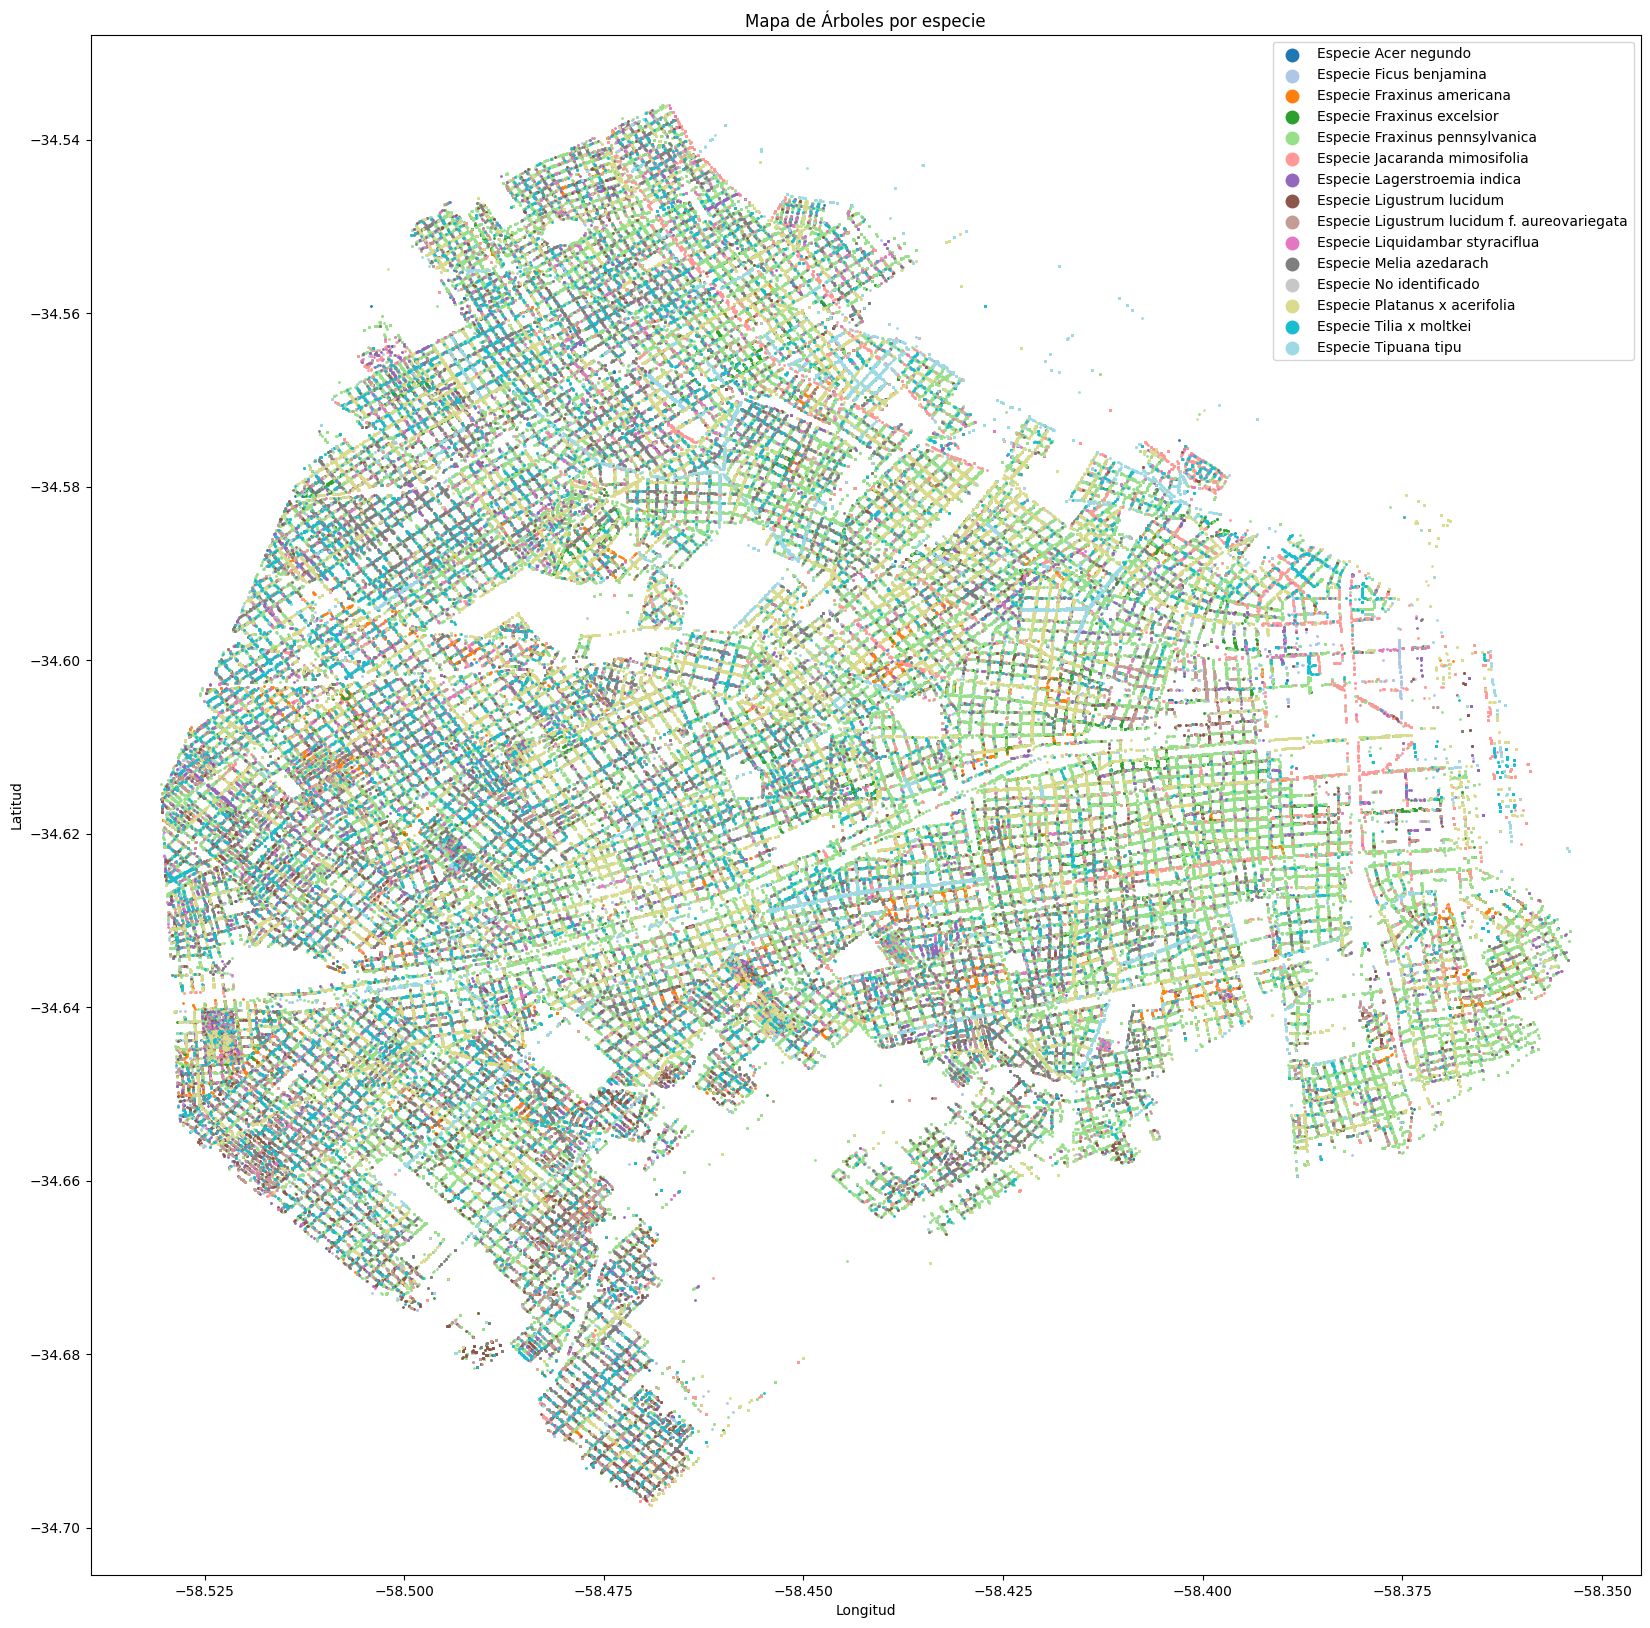

In [32]:


plt.figure(figsize=(20, 20))
categorias = sorted(top12.index)
colores = plt.cm.get_cmap('tab20', len(categorias))

for i, especie in enumerate(categorias):
    subset = datos_arbolado[datos_arbolado['nombre_cientifico'] == especie]
    plt.scatter(
        subset['long'],
        subset['lat'],
        s=1,
        color=colores(i),
        label=f'Especie {(especie)}'
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles por especie")
plt.legend(markerscale=9)
plt.show()

## Ancho_acera

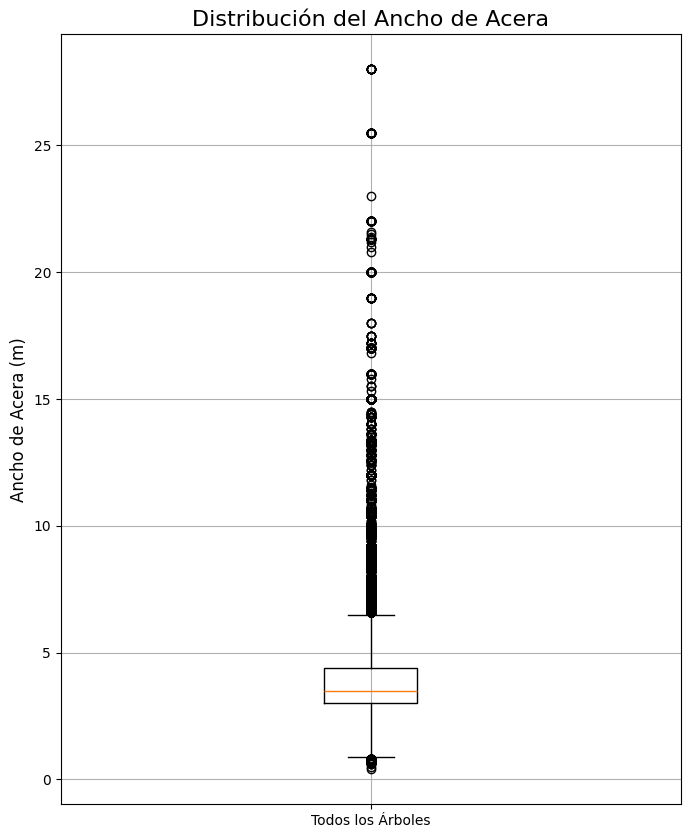

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df= pd.DataFrame()
datos_arbolado['ancho_acera_limpio'] = datos_arbolado['ancho_acera'].astype(str).str.replace(',', '.')

# Convertimos a numérico. 
# errors='coerce' transforma valores como 'Sin acera' en NaN (Not a Number)
datos_arbolado['ancho_acera_limpio'] = pd.to_numeric(datos_arbolado['ancho_acera_limpio'], errors='coerce')


# --- 2. CREACIÓN DEL GRÁFICO ---
fig, ax = plt.subplots(figsize=(8, 10))

# Usamos la columna limpia y .dropna() para eliminar los NaN
ax.boxplot(datos_arbolado['ancho_acera_limpio'].dropna())

# --- 3. CONFIGURACIÓN DEL GRÁFICO ---
ax.set_title('Distribución del Ancho de Acera', fontsize=16)
ax.set_ylabel('Ancho de Acera (m)', fontsize=12)
ax.set_xticklabels(['Todos los Árboles'])
ax.grid(True)

plt.show()

In [34]:

datos_arbolado[datos_arbolado['ancho_acera_limpio']<1]['calle_nombre'].value_counts()

calle_nombre
Crámer                       97
Fernández Espiro Diego       13
Gutenberg                     8
Sumaca Santísima Trinidad     8
Plaza                         8
Zeballos Estanislao           3
Santiago Costamagna           2
Pérez Galdós Benito Av.       1
Suárez                        1
Ochoa Enrique                 1
Azurduy Juana                 1
Tres Arroyos                  1
Yerbal                        1
Acassuso                      1
San Mateo                     1
Güemes                        1
Amenábar                      1
Conesa                        1
Name: count, dtype: int64

se analisa las aceras que tengas valores aparentemente outliers
Por ejemplo la calle cramer es la que mas se repite en los que tienen acera chica, eso se debe a que la calle tiene una parte donde da junto a la via, y esa acera es muy pequeña

son caso particulares de ciertos sectores donde por diferentes causas las aceras son mas pequeñas, por lo tanto se toma la decicion de eliminarlos

In [35]:
datos_arbolado= datos_arbolado[datos_arbolado['ancho_acera_limpio']>1]

Ahora se hace el analisis pero con los que tengan acera de diametro alto

En este caos podemos ver que el outlier es debido a una falla en la escritura. Asi que planteamos una imputacion por vecinos cercanos, para poder determinar los anchos de las aceras que parezcan outliers.

In [36]:
datos_arbolado[(datos_arbolado['calle_nombre']=='Pedernera') & (datos_arbolado['calle_altura']==400)]

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol,ancho_acera_limpio
93204,-58.461803,-34.634639,7.0,565,Pedernera,400.0,4920,Tilia x moltkei,28,Ocupada,Regular,A nivel,24.0,8.0,28.0
93305,-58.461986,-34.634207,7.0,565,Pedernera,400.0,4180,Fraxinus pennsylvanica,2.8,Ocupada,Fuera de línea,Bajo nivel,12.0,4.0,2.8
93306,-58.461986,-34.634207,7.0,565,Pedernera,400.0,4180,Platanus x acerifolia,2.8,Ocupada,Regular,A nivel,70.0,13.0,2.8
93307,-58.461986,-34.634207,7.0,565,Pedernera,400.0,4180,Platanus x acerifolia,2.8,Ocupada,Regular,Elevada,11.0,4.0,2.8
100041,-58.461862,-34.634715,7.0,564,Pedernera,400.0,485,Otra,3.2,Sobreocupada,Regular,Bajo nivel,2.0,2.0,3.2
100042,-58.461862,-34.634715,7.0,564,Pedernera,400.0,485,Platanus x acerifolia,3.2,Ocupada,Regular,Bajo nivel,0.0,NaN,3.2
100043,-58.461908,-34.634606,7.0,564,Pedernera,400.0,475,Platanus x acerifolia,3.2,Ocupada,Regular,A nivel,100.0,16.0,3.2
100044,-58.461937,-34.634539,7.0,564,Pedernera,400.0,471,Platanus x acerifolia,3.2,Ocupada,Regular,Bajo nivel,60.0,15.0,3.2
100045,-58.461966,-34.634470,7.0,564,Pedernera,400.0,463,Tilia x moltkei,3.2,Ocupada,Regular,A nivel,30.0,8.0,3.2
100046,-58.462003,-34.634384,7.0,564,Pedernera,400.0,435,Tilia x moltkei,3.2,Ocupada,Regular,Elevada,30.0,7.0,3.2


In [37]:
import pandas as pd
import numpy as np

# Asumo que 'datos_arbolado' es tu DataFrame

# --- 1. LIMPIEZA DE 'calle_altura' ---
print("Limpiando 'calle_altura'...")

# Convertimos toda la columna a string para poder usar .str.extract()
# .astype(str) es más seguro para manejar números, NaNs, y texto
df_altura_temp = datos_arbolado['calle_altura'].astype(str)

# Usamos una expresión regular para extraer el *primer* grupo de números
# ^(\d+) significa:
# ^ : "desde el inicio del string"
# (\d+) : "captura ( ) uno o más dígitos (\d+)"
# Esto encontrará '2000' en '2000-1900' y '1900' en '1900'.
df_altura_limpia = df_altura_temp.str.extract(r'^(\d+)', expand=False)

# Convertimos la nueva columna limpia a numérico (float64).
# errors='coerce' convertirá cualquier cosa que no sea un número 
# (ej. 'S/N' o un texto vacío) en NaN (Nulo).
datos_arbolado['calle_altura'] = pd.to_numeric(df_altura_limpia, errors='coerce')

nulos_altura = datos_arbolado['calle_altura'].isnull().sum()
if nulos_altura > 0:
    print(f"Se encontraron/crearon {nulos_altura} NaNs en 'calle_altura' (por valores como 'S/N', 'SinDato', etc.).")
    
print("Limpieza de 'calle_altura' completada. La columna es ahora float64.")

Limpiando 'calle_altura'...
Limpieza de 'calle_altura' completada. La columna es ahora float64.


In [38]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer

# 1. PREPARACIÓN de 'ancho_acera' (la columna que queremos corregir)
UMBRAL_OUTLIER = 7 # Umbral para 'ancho_acera' (ej. 28)
datos_arbolado['ancho_acera_corregido'] = datos_arbolado['ancho_acera_limpio']
# Convertimos outliers a NaN para que kNN los impute
datos_arbolado.loc[datos_arbolado['ancho_acera_corregido'] > UMBRAL_OUTLIER, 'ancho_acera_corregido'] = np.nan

print(f"Valores de 'ancho_acera' a imputar (outliers): {datos_arbolado['ancho_acera_corregido'].isnull().sum()}")

# 2. DEFINICIÓN DE FEATURES para el kNN
# Usaremos 'calle_nombre' y la 'calle_altura' (que acabamos de limpiar)
features = ['calle_nombre', 'calle_altura', 'ancho_acera_corregido']

# 3. PIPELINES DE PREPROCESAMIENTO
# kNN necesita que 'calle_nombre' y 'calle_altura' estén limpias y escaladas

# Pipeline para 'calle_altura' (numérica)
numeric_transformer = Pipeline(steps=[
    # 1. Rellena los NaNs que creamos (ej. de 'S/N') con la mediana
    ('imputer', SimpleImputer(strategy='median')),
    # 2. Escala los números (ej. 2000 y 4000)
    ('scaler', StandardScaler())
])

# Pipeline para 'calle_nombre' (categórica)
categorical_transformer = Pipeline(steps=[
    # 1. Rellena NaNs (si hay) con un valor constante
    ('imputer', SimpleImputer(strategy='constant', fill_value='DESCONOCIDA')),
    # 2. Convierte el texto (ej. 'Av. Rivadavia') a un número
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Usamos ColumnTransformer para aplicar los pipelines a las columnas correctas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, ['calle_nombre']),
        ('num', numeric_transformer, ['calle_altura'])
    ],
    remainder='passthrough' # Mantenemos 'ancho_acera_corregido' (con sus NaNs) intacta
)

# 4. CREAR EL IMPUTADOR KNN
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

# 5. CREAR Y EJECUTAR EL PIPELINE TOTAL
pipeline_total = Pipeline(steps=[
    # PASO 1: Limpia y transforma 'calle_nombre' y 'calle_altura'
    ('preprocessor', preprocessor),
    # PASO 2: Usa esos datos limpios para imputar 'ancho_acera_corregido'
    ('imputer_knn', knn_imputer)
])

# Ajustamos y transformamos (fit_transform)
df_imputado = pipeline_total.fit_transform(datos_arbolado[features])

# 6. RECONSTRUIR EL DATAFRAME Y ACTUALIZAR 'datos_arbolado'
# Obtenemos los nombres de las columnas (pueden cambiar)
col_names = list(preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(['calle_nombre']))
col_names.append('calle_altura')
col_names.append('ancho_acera_corregido') # Esta es la columna que nos interesa

df_imputado_named = pd.DataFrame(
    df_imputado, 
    columns=col_names,
    index=datos_arbolado.index 
)

# Actualizamos el DataFrame original con la columna final imputada
datos_arbolado['ancho_acera'] = df_imputado_named['ancho_acera_corregido']

print("\n--- ¡Corrección de 'ancho_acera' completada! ---")
print(datos_arbolado['ancho_acera'].describe())

Valores de 'ancho_acera' a imputar (outliers): 5986

--- ¡Corrección de 'ancho_acera' completada! ---
count    349177.000000
mean          3.679488
std           0.948969
min           1.010000
25%           3.000000
50%           3.500000
75%           4.400000
max           7.000000
Name: ancho_acera, dtype: float64


In [39]:
datos_arbolado[(datos_arbolado['calle_nombre']=='Solís') & (datos_arbolado['calle_altura']==2000)]

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol,ancho_acera_limpio,ancho_acera_corregido
8820,-58.388971,-34.632353,1.0,685,Solís,2000,20850,Ficus benjamina,3.00,Ocupada,Regular,Elevada,37.0,10.0,3.0,3.0
8821,-58.388989,-34.632190,1.0,685,Solís,2000,20710,Fraxinus pennsylvanica,3.00,Ocupada,Regular,Elevada,31.0,10.0,3.0,3.0
8822,-58.389008,-34.632029,1.0,685,Solís,2000,20510,Ficus benjamina,3.00,Ocupada,Regular,A nivel,53.0,12.0,3.0,3.0
8823,-58.389036,-34.631787,1.0,685,Solís,2000,20250,Otra,3.00,Ocupada,Regular,Bajo nivel,29.0,15.0,3.0,3.0
8824,-58.389059,-34.631583,1.0,685,Solís,2000,20090,Fraxinus americana,3.00,Ocupada,Regular,A nivel,19.0,8.0,3.0,3.0
9149,-58.388961,-34.632436,1.0,685,Solís,2000,20930,Melia azedarach,3.00,Ocupada,Ochava,A nivel,74.0,11.0,3.0,3.0
9150,-58.388971,-34.632353,1.0,685,Solís,2000,20850,Melia azedarach,3.00,Ocupada,Regular,Bajo nivel,89.0,13.0,3.0,3.0
9151,-58.388998,-34.632110,1.0,685,Solís,2000,20650,Lagerstroemia indica,3.00,Ocupada,Regular,Bajo nivel,11.0,6.0,3.0,3.0
9152,-58.389017,-34.631949,1.0,685,Solís,2000,20490,Fraxinus pennsylvanica,3.00,Ocupada,Regular,Bajo nivel,24.0,10.0,3.0,3.0
9153,-58.389036,-34.631787,1.0,685,Solís,2000,20230,Fraxinus pennsylvanica,3.00,Ocupada,Regular,Bajo nivel,45.0,11.0,3.0,3.0


In [40]:
datos_arbolado[datos_arbolado['ancho_acera']>10]

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol,ancho_acera_limpio,ancho_acera_corregido


In [41]:
datos_arbolado= datos_arbolado.drop('ancho_acera_limpio',axis=1)
datos_arbolado= datos_arbolado.drop('ancho_acera_corregido',axis=1)


In [42]:
datos_arbolado


,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,NaN,Esmeralda,1000,11200,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,1.0,NaN,Pellegrini Carlos,1300,13450,Otra,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,1.0,NaN,Arroyo,800,8480,Fraxinus pennsylvanica,4.0,Ocupada,Regular,A nivel,7.0,6.0
5,-58.381043,-34.591584,1.0,NaN,Arroyo,900,9700,Fraxinus pennsylvanica,3.5,Ocupada,Regular,A nivel,29.0,15.0
6,-58.380968,-34.591576,1.0,NaN,Arroyo,900,9620,Fraxinus pennsylvanica,4.5,Ocupada,Regular,A nivel,21.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370051,-58.468342,-34.587871,15.0,126,Estomba,300,<NA>,Tipuana tipu,4.0,Ocupada,Regular,A Nivel,83.0,20.0
370052,-58.468342,-34.587871,15.0,126,Estomba,300,<NA>,Tipuana tipu,4.0,Ocupada,Regular,A Nivel,76.0,20.0
370053,-58.468342,-34.587871,15.0,126,Estomba,300,<NA>,Tipuana tipu,4.0,Ocupada,Regular,A Nivel,85.0,20.0
370054,-58.468342,-34.587871,15.0,126,Estomba,300,<NA>,Tipuana tipu,4.0,Ocupada,Regular,A Nivel,84.0,20.0


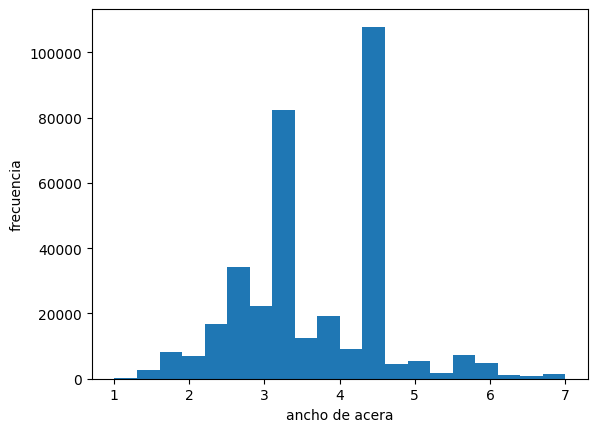

In [43]:
bins=20

plt.hist(datos_arbolado['ancho_acera'], bins=bins)
plt.xlabel('ancho de acera')
plt.ylabel('frecuencia')
plt.show()

## Estado_plantera

In [44]:
datos_arbolado['estado_plantera']= datos_arbolado['estado_plantera'].str.lower()


In [45]:



dic= {
    'vacía': 0,
    'subocupada':1,
    'ocupada': 2,
    'sobreocupada': 3
}
datos_arbolado['estado_plantera']=datos_arbolado['estado_plantera'].map(dic)
cantidad= datos_arbolado['estado_plantera'].value_counts()
clase_plantera= datos_arbolado['estado_plantera']


In [46]:

print(datos_arbolado['estado_plantera'].value_counts())
print(datos_arbolado['estado_plantera'].isna().sum())

estado_plantera
2.0    311904
3.0     36610
1.0       502
0.0         3
Name: count, dtype: int64
158


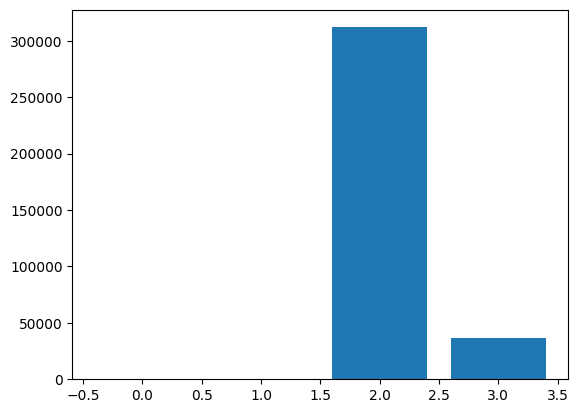

In [47]:
plt.bar(datos_arbolado['estado_plantera'].value_counts().index,datos_arbolado['estado_plantera'].value_counts().values)
plt.show()

## Ubicacion_plantera


In [48]:

datos_arbolado['ubicacion_plantera']=datos_arbolado['ubicacion_plantera'].str.lower()
datos_arbolado['ubicacion_plantera'].value_counts()

mapeo_limpieza = {
    'regular': 'Regular',
    'ochava': 'Ochava',
    'o': 'Ochava',
    'och': 'Ochava',       
    'ochva': 'Ochava',    
    'fuera de línea': 'Fuera de linea'
}
print(datos_arbolado['ubicacion_plantera'].value_counts())

ubicacion_plantera
regular               322256
ochava                 20941
fuera de línea          5074
regular                  192
ocupada                   40
fuera nivel               36
cantero grande            13
o                         12
ochava/fuera línea         3
sobreocupada               2
och                        2
fuera línea,ochava         1
elevada                    1
ochva                      1
subocupada                 1
Name: count, dtype: int64


In [49]:


datos_arbolado['ubicacion_plantera']= datos_arbolado['ubicacion_plantera'].map(mapeo_limpieza)
print(datos_arbolado['ubicacion_plantera'].value_counts())

ubicacion_plantera
Regular           322256
Ochava             20956
Fuera de linea      5074
Name: count, dtype: int64


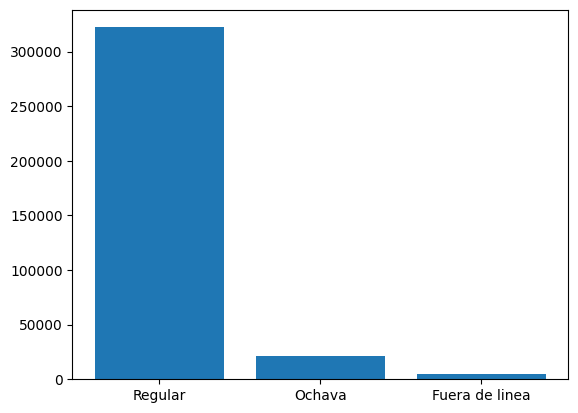

In [50]:
plt.bar(datos_arbolado['ubicacion_plantera'].value_counts().index, datos_arbolado['ubicacion_plantera'].value_counts().values)
plt.show()

## Nivel_plantera

In [51]:
datos_arbolado['nivel_plantera'].value_counts()

nivel_plantera
A nivel        218547
Elevada         75026
Bajo nivel      34106
A Nivel         19761
Bajo Nivel        784
AN                 85
A nivel            47
A  Nivel           32
EL                 20
Elevadas           18
BN                 12
Bajo Bivel          9
Elevado             5
Eleveda             5
Reducida            5
elevada             4
ELEVADA             2
Baja Nivel          2
el                  2
bajo nivel          2
a Nivel             1
Regular             1
Bajo  nivel         1
Ochava              1
An                  1
Name: count, dtype: int64

In [52]:
datos_arbolado['nivel_plantera']= datos_arbolado['nivel_plantera'].str.lower().str.strip()
print(datos_arbolado['nivel_plantera'].value_counts())

nivel_plantera
a nivel        238356
elevada         75032
bajo nivel      34892
an                 86
a  nivel           32
el                 22
elevadas           18
bn                 12
bajo bivel          9
elevado             5
reducida            5
eleveda             5
baja nivel          2
regular             1
ochava              1
bajo  nivel         1
Name: count, dtype: int64


In [53]:


mapeo_ordinal = {
    # Nivel 0: Bajo Nivel
    'bajo nivel': 0,
    'bajo bivel': 0,
    'baja nivel': 0,
    'bajo  nivel': 0,
    'bn': 0,

    # Nivel 1: A Nivel (el estándar)
    'a nivel': 1,
    'a  nivel': 1,
    'an': 1,
    'a nvel': 1, # (Asumimos posibles typos)
    
    # Nivel 2: Elevada
    'elevada': 2,
    'elevado': 2,
    'elevadas': 2,
    'eleveda': 2,
    'el': 2,
    'elevada': 2
}
datos_arbolado['nivel_plantera']= datos_arbolado['nivel_plantera'].map(mapeo_ordinal)
print(datos_arbolado['nivel_plantera'].value_counts())

nivel_plantera
1.0    238474
2.0     75082
0.0     34916
Name: count, dtype: int64


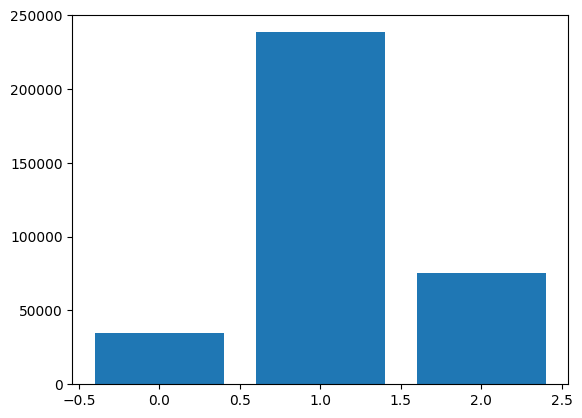

In [54]:
plt.bar(datos_arbolado['nivel_plantera'].value_counts().index, datos_arbolado['nivel_plantera'].value_counts().values)
plt.show()

## Diametro_altura_pecho

(array([4.8211e+04, 5.6383e+04, 7.5922e+04, 6.3509e+04, 3.9514e+04,
        2.5262e+04, 1.8888e+04, 1.0947e+04, 5.8780e+03, 2.2650e+03,
        1.1370e+03, 4.9000e+02, 2.4900e+02, 1.0200e+02, 4.4000e+01,
        3.9000e+01, 2.9000e+01, 1.3000e+01, 1.4000e+01, 1.6000e+01]),
 array([  0. ,   9.9,  19.8,  29.7,  39.6,  49.5,  59.4,  69.3,  79.2,
         89.1,  99. , 108.9, 118.8, 128.7, 138.6, 148.5, 158.4, 168.3,
        178.2, 188.1, 198. ]),
 <BarContainer object of 20 artists>)

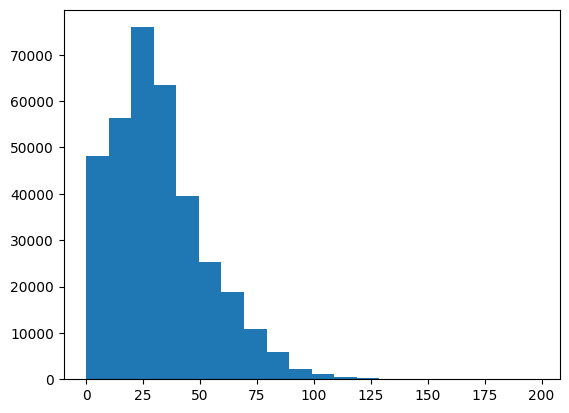

In [55]:
plt.hist(datos_arbolado['diametro_altura_pecho'], bins=20)

In [56]:
outliers_diametro= datos_arbolado[datos_arbolado['diametro_altura_pecho']>150]
outliers_diametro['calle_nombre'].value_counts()

calle_nombre
Morán Pedro                      5
Holmberg                         2
Pérez Roque                      2
La Pampa                         2
Dumont Santos                    2
                                ..
D'Esposito Arnaldo               1
20 de Septiembre                 1
Rivadavia Martín Comodoro Av.    1
Roldán Belisario Av.             1
Punta Arenas  Av.                1
Name: count, Length: 81, dtype: int64

In [57]:
outliers_diametro[outliers_diametro['calle_nombre']=='Holmberg']

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
265795,-58.472113,-34.574587,12.0,NaN,Holmberg,1800,18430,Melia azedarach,3.2,2.0,Regular,1.0,160.0,10.0
328263,-58.468415,-34.579893,15.0,67,Holmberg,1200,1270,Melia azedarach,4.4,3.0,Regular,2.0,153.0,15.0


In [58]:
datos_arbolado[(datos_arbolado['calle_nombre']== 'Holmberg') & (datos_arbolado['calle_altura']==1800)]

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
259776,-58.472498,-34.574301,12.0,NaN,Holmberg,1800,18880,Tilia x moltkei,3.2,2.0,Ochava,1.0,24.0,9.0
260080,-58.472154,-34.574707,12.0,NaN,Holmberg,1800,18400,Melia azedarach,3.2,2.0,Regular,1.0,53.0,14.0
260081,-58.472043,-34.574839,12.0,NaN,Holmberg,1800,18180,Tilia x moltkei,3.2,3.0,Regular,1.0,43.0,13.0
260082,-58.472043,-34.574839,12.0,NaN,Holmberg,1800,18180,Otra,3.2,2.0,Regular,1.0,11.0,7.0
260083,-58.472043,-34.574839,12.0,NaN,Holmberg,1800,18180,Ficus benjamina,3.2,2.0,Ochava,1.0,94.0,14.0
260084,-58.472263,-34.574578,12.0,NaN,Holmberg,1800,18560,Melia azedarach,3.2,2.0,Regular,1.0,85.0,14.0
260085,-58.472318,-34.574514,12.0,NaN,Holmberg,1800,18680,Otra,3.2,2.0,Regular,0.0,12.0,6.0
260086,-58.472100,-34.574771,12.0,NaN,Holmberg,1800,18280,Melia azedarach,3.2,2.0,Regular,1.0,59.0,13.0
260087,-58.472208,-34.574643,12.0,NaN,Holmberg,1800,18520,Melia azedarach,3.2,2.0,Regular,1.0,47.0,14.0
261183,-58.472462,-34.574344,12.0,NaN,Holmberg,1800,18820,Fraxinus pennsylvanica,3.2,2.0,Regular,0.0,36.0,11.0


In [59]:
datos_arbolado['diametro_altura_pecho'].describe()

count    348912.000000
mean         31.904807
std          21.133399
min           0.000000
25%          17.000000
50%          29.000000
75%          43.000000
max         198.000000
Name: diametro_altura_pecho, dtype: float64

Se toma la decicion de eliminar los que tengan diametro mayor a 150, dado que en la mayoria son casos erroneos y en otros al ser pequeña cantidad no afecta el analisis y son casos especiales


In [60]:
datos_arbolado= datos_arbolado[datos_arbolado['diametro_altura_pecho']<150]


In [61]:
datos_arbolado['diametro_altura_pecho'].isna().sum()

np.int64(0)

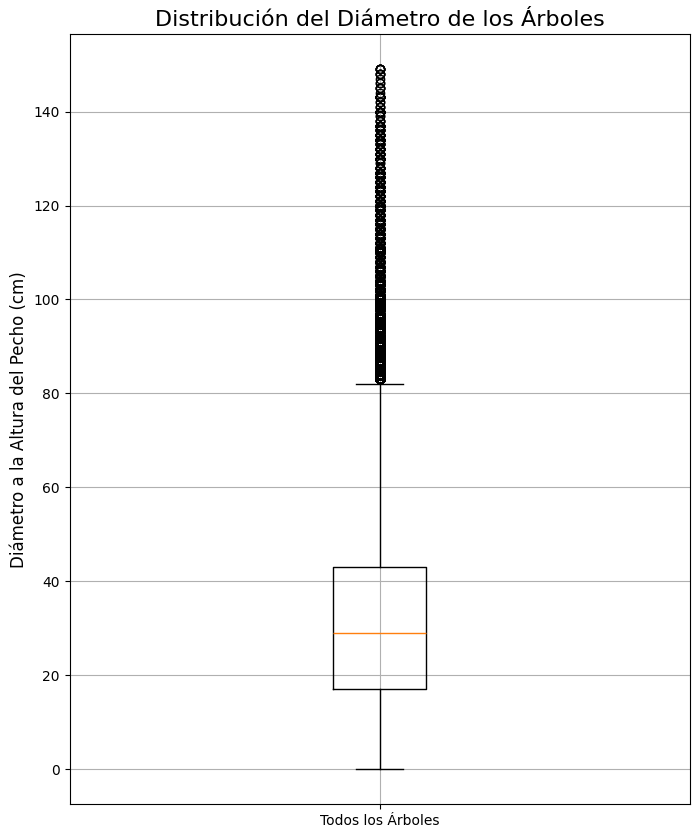

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumo que ya tenés el DataFrame limpio y cargado como 'df_clean'
# df_clean = ...


# Preparamos la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 10))

# La función boxplot de matplotlib recibe directamente la serie de datos
# Es importante usar .dropna() para eliminar valores nulos que pueden dar error
ax.boxplot(datos_arbolado['diametro_altura_pecho'].dropna())

# Configuramos el gráfico
ax.set_title('Distribución del Diámetro de los Árboles', fontsize=16)
ax.set_ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
ax.set_xticklabels(['Todos los Árboles']) # Le ponemos nombre al eje X
ax.grid(True) # Añadimos una grilla

plt.show()

Vamos a analisar los que tengan diametro menor a 5 centrimetros

In [63]:
datos_arbolado[datos_arbolado['diametro_altura_pecho']<2]['nombre_cientifico'].value_counts()
datos_arbolado= datos_arbolado[datos_arbolado['diametro_altura_pecho']>=2]


In [64]:
datos_arbolado['diametro_altura_pecho'].isna().sum()

np.int64(0)

In [65]:
datos_arbolado.to_pickle('../data/datos_arbolado')

In [66]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340147 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   340147 non-null  float64
 1   lat                    340147 non-null  float64
 2   comuna                 340147 non-null  float64
 3   manzana                205444 non-null  object 
 4   calle_nombre           340147 non-null  object 
 5   calle_altura           340147 non-null  int64  
 6   calle_chapa            336784 non-null  Int32  
 7   nombre_cientifico      340147 non-null  object 
 8   ancho_acera            340147 non-null  float64
 9   estado_plantera        339998 non-null  float64
 10  ubicacion_plantera     339288 non-null  object 
 11  nivel_plantera         339478 non-null  float64
 12  diametro_altura_pecho  340147 non-null  float64
 13  altura_arbol           338991 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

## Altura_arbol

In [67]:
datos_arbolado[datos_arbolado['altura_arbol'].isna()]['comuna'].value_counts()

comuna
4.0     186
11.0    122
9.0     122
10.0    109
12.0    104
15.0     74
5.0      70
13.0     67
7.0      58
3.0      52
8.0      51
14.0     47
2.0      32
6.0      32
1.0      30
Name: count, dtype: int64

Analiso en la comuna 5 porque hay varios que son nulos


In [68]:
datos_arbolado['altura_arbol'].isna().sum()
datos_arbolado= datos_arbolado[datos_arbolado['altura_arbol'].notna()]


In [69]:
datos_arbolado['altura_arbol'].isna().sum()

np.int64(0)

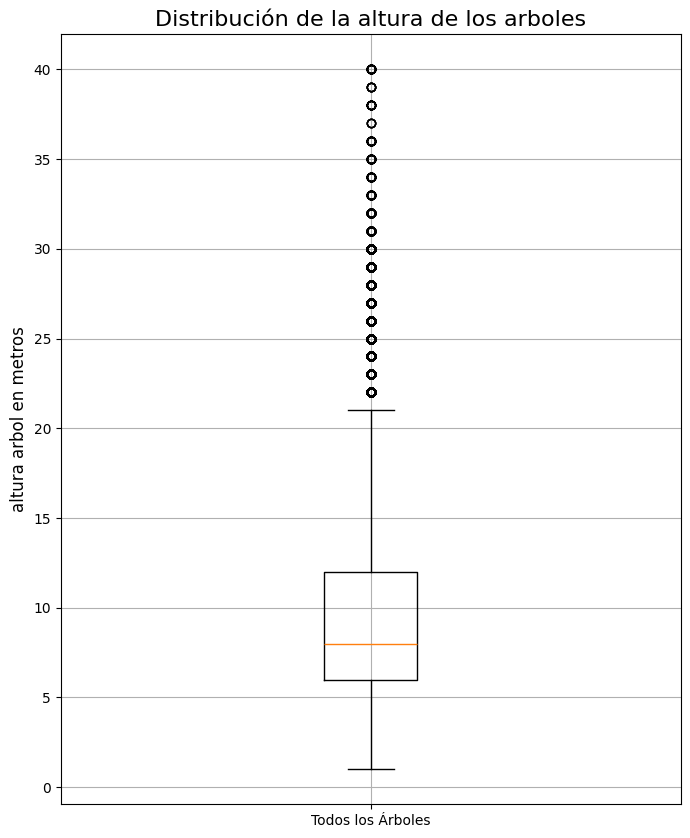

In [70]:
# Preparamos la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 10))


# La función boxplot de matplotlib recibe directamente la serie de datos
# Es importante usar .dropna() para eliminar valores nulos que pueden dar error
ax.boxplot(datos_arbolado['altura_arbol'].dropna())

# Configuramos el gráfico
ax.set_title('Distribución de la altura de los arboles', fontsize=16)
ax.set_ylabel('altura arbol en metros', fontsize=12)
ax.set_xticklabels(['Todos los Árboles']) # Le ponemos nombre al eje X
ax.grid(True) # Añadimos una grilla

plt.show()

In [71]:
datos_arbolado[datos_arbolado['altura_arbol']>39]

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
90,-58.381536,-34.592402,1.0,NaN,Pellegrini Carlos,1300,13370,Otra,4.5,2.0,Regular,2.0,3.0,40.0
28042,-58.394735,-34.613740,3.0,NaN,Sarandí,300,3850,Fraxinus pennsylvanica,3.0,2.0,Regular,0.0,19.0,40.0
76626,-58.443372,-34.608020,6.0,NaN,Díaz Vélez Av.,5400,54770,Platanus x acerifolia,6.0,2.0,Regular,2.0,35.0,40.0
95653,-58.436798,-34.637094,7.0,489,Castañares Av.,1300,13100,Jacaranda mimosifolia,6.0,3.0,Regular,2.0,54.0,40.0
110799,-58.455935,-34.621240,6.0,106,Avellaneda Av.,1800,1800,Platanus x acerifolia,4.0,2.0,Ochava,0.0,64.0,40.0
110800,-58.455935,-34.621240,6.0,106,Avellaneda Av.,1800,1800,Platanus x acerifolia,5.5,2.0,Ochava,1.0,57.0,40.0
110801,-58.455935,-34.621240,6.0,106,Avellaneda Av.,1800,1800,Platanus x acerifolia,5.5,2.0,Ochava,0.0,41.0,40.0
110802,-58.455935,-34.621240,6.0,106,Avellaneda Av.,1800,1800,Platanus x acerifolia,5.5,2.0,Regular,0.0,41.0,40.0
110805,-58.455935,-34.621240,6.0,106,Avellaneda Av.,1800,1800,Platanus x acerifolia,5.5,2.0,Regular,1.0,41.0,40.0
110811,-58.455935,-34.621240,6.0,106,Avellaneda Av.,1800,1800,Platanus x acerifolia,5.5,2.0,Regular,1.0,57.0,40.0


In [72]:
datos_arbolado.to_pickle('../data/datos_arbolado')

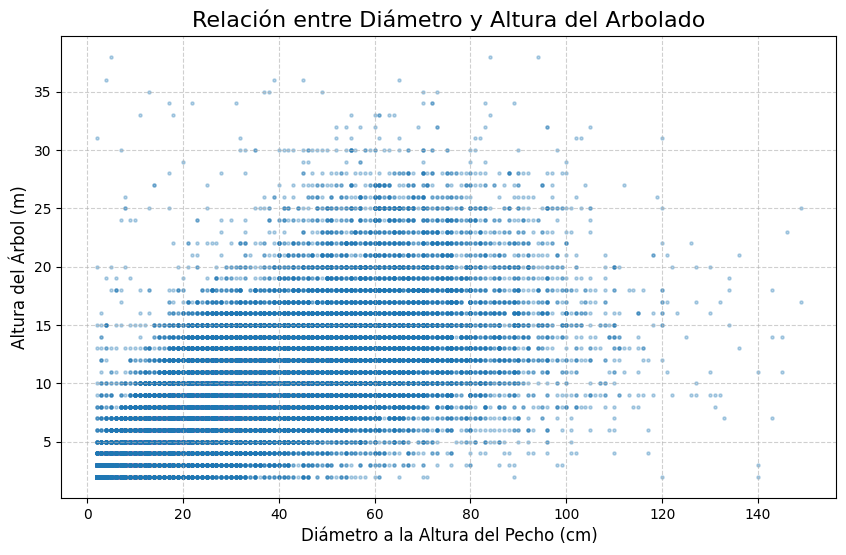

----------------------------------------
Resultados de Correlación (sobre 338962 árboles):
  Correlación de Pearson (r): 0.6711
 Correlación de Spearman (ρ): 0.7119
----------------------------------------


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumo que tu DataFrame se llama 'datos_arbolado'
# ---- 1. Limpieza y Preparación ----

# Creamos una copia para no modificar el original
df_plot = datos_arbolado.copy()

# (Paso de seguridad) Aseguramos que ambas columnas sean numéricas
# 'coerce' convertirá cualquier texto (como 'Sin dato') en NaN
df_plot['diametro_altura_pecho'] = pd.to_numeric(df_plot['diametro_altura_pecho'], errors='coerce')
df_plot['altura_arbol'] = pd.to_numeric(df_plot['altura_arbol'], errors='coerce')

# Eliminamos filas donde falte alguno de estos dos datos
df_plot.dropna(subset=['diametro_altura_pecho', 'altura_arbol'], inplace=True)

# ---- 2. Filtrado de Outliers ----
# Filtramos valores extremos que "aplastarían" el gráfico
# Ej: Diámetros > 200cm o Alturas > 40m
df_filtrado = df_plot[
    (df_plot['diametro_altura_pecho'] > 0) & (df_plot['diametro_altura_pecho'] < 200) &
    (df_plot['altura_arbol'] > 0) & (df_plot['altura_arbol'] < 40)
]

# ---- 3. Muestreo (Sampling) ----
# Tomamos una muestra aleatoria de 50,000 puntos para evitar el overplotting
df_sample = df_filtrado.sample(n=min(50000, len(df_filtrado)), random_state=42)

# ---- 4. Creación del Gráfico ----
plt.figure(figsize=(10, 6))
plt.scatter(
    df_sample['diametro_altura_pecho'],
    df_sample['altura_arbol'],
    alpha=0.3,  # Transparencia para ver la densidad
    s=5         # Tamaño pequeño del punto
)

plt.title('Relación entre Diámetro y Altura del Arbolado', fontsize=16)
plt.xlabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.ylabel('Altura del Árbol (m)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# ---- 3. Muestreo (Sampling) ----
# ... (tu código de muestreo para el gráfico) ...
df_sample = df_filtrado.sample(n=min(50000, len(df_filtrado)), random_state=42)

# ==========================================================
# AÑADIR AQUÍ EL CÁLCULO DE CORRELACIÓN
# ==========================================================
# Usamos df_filtrado (todos los datos limpios) para el cálculo estadístico

# --- Método 1: Correlación de Pearson (la más común) ---
# Mide la relación LINEAL
corr_pearson = df_filtrado['diametro_altura_pecho'].corr(
    df_filtrado['altura_arbol'], 
    method='pearson'
)

# --- Método 2: Correlación de Spearman ---
# Mide la relación MONOTÓNICA (si una sube, la otra también, 
# aunque no sea una línea recta). Es útil si la relación se "aplana".
corr_spearman = df_filtrado['diametro_altura_pecho'].corr(
    df_filtrado['altura_arbol'], 
    method='spearman'
)

print("-" * 40)
print(f"Resultados de Correlación (sobre {len(df_filtrado)} árboles):")
print(f"  Correlación de Pearson (r): {corr_pearson:.4f}")
print(f" Correlación de Spearman (ρ): {corr_spearman:.4f}")
print("-" * 40)
# ==========================================================

# ---- 4. Creación del Gráfico ----
# (Tu código de plt.scatter() sigue aquí, usando df_sample)
plt.figure(figsize=(10, 6))
# ... (el resto de tu código de plotting) ...

## Relacion ancho acera con estado plantera sobreocupada

In [74]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338991 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   338991 non-null  float64
 1   lat                    338991 non-null  float64
 2   comuna                 338991 non-null  float64
 3   manzana                204681 non-null  object 
 4   calle_nombre           338991 non-null  object 
 5   calle_altura           338991 non-null  int64  
 6   calle_chapa            335639 non-null  Int32  
 7   nombre_cientifico      338991 non-null  object 
 8   ancho_acera            338991 non-null  float64
 9   estado_plantera        338842 non-null  float64
 10  ubicacion_plantera     338136 non-null  object 
 11  nivel_plantera         338324 non-null  float64
 12  diametro_altura_pecho  338991 non-null  float64
 13  altura_arbol           338991 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

In [75]:
datos_arbolado.to_pickle('../data/datos_arbolado')

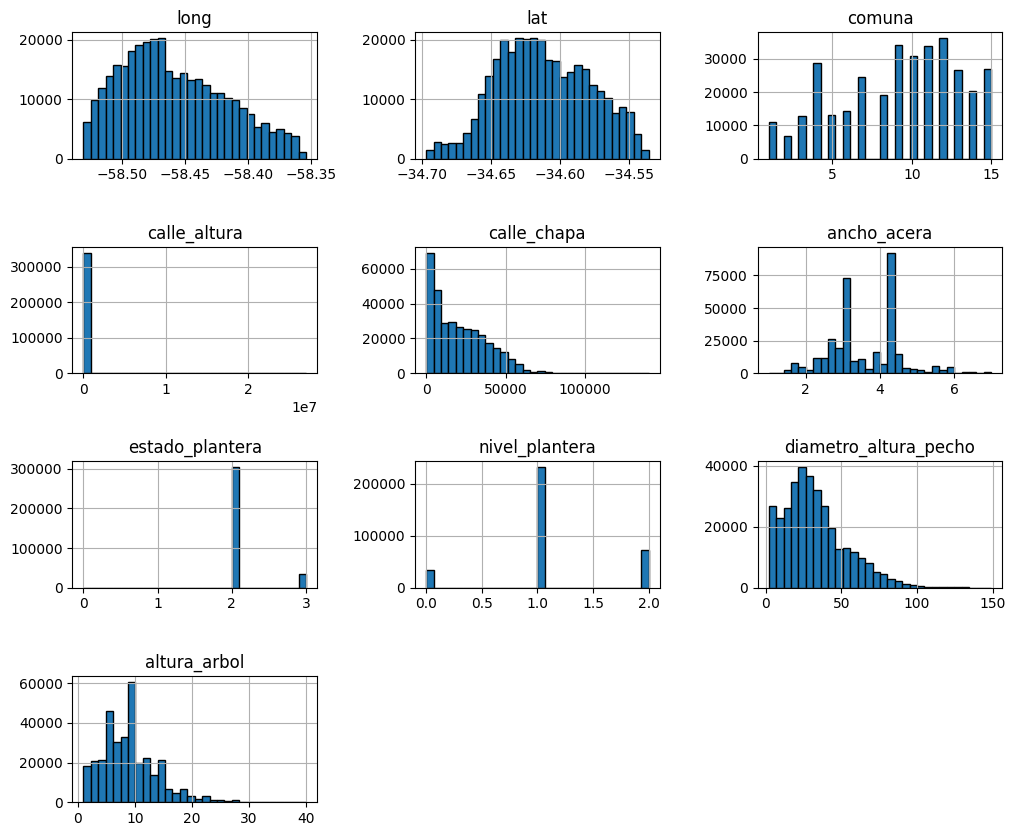

In [76]:
datos_arbolado.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)